<a href="https://colab.research.google.com/github/xwx-codingweb/XIA_DSPN_S26/blob/master/ExerciseSubmissions/18_principal-component-methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 18: Principal component methods

This homework assignment is designed to give you an intuition on principal component approaches to understanding high dimensional statistical relationships.

Like earlier homework, you will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading data (1 point)

We are going to look for low dimensional relationships between brain volume measures and working memory capacity.

First, we will need to load the `pls`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [4]:
# WRITE YOUR CODE HERE
install.packages('pls')

library(tidyverse)
library(ggplot2)
library(pls)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘pls’


The following object is masked from ‘package:stats’:

    loadings




Use `read.csv` function to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file in the **hcp_data** folder.

(a) Using the tidyverse tools, make a new dataframe `d1` that only includes the Flanker Task performance (`Flanker_Unadj`) and *all* freesurfer **volume** measures for the right and left hemispheres together. Remove both "na's" and any columns that consist of only zeros.

Hint: Look up using the `ends_with` function to only select variables that end with "_Vol"

Use the `head` function to look at the first few rows of each data frame.

In [9]:
# WRITE YOUR CODE HERE
# load data
d <- read.csv("https://raw.githubusercontent.com/xwx-codingweb/XIA_DSPN_S26/master/Exercise%20datasets/hcp_data/unrestricted_trimmed_1_7_2020_10_50_44.csv")

head(d)

d1 <- d %>%
  select(Flanker_Unadj, ends_with("_Vol")) %>%
  select(where(~ any(. != 0, na.rm = TRUE))) %>%
  drop_na()

head(d1)

,Subject,Release,Acquisition,Gender,Age,MMSE_Score,PSQI_Score,PSQI_Comp1,PSQI_Comp2,PSQI_Comp3,⋯,Noise_Comp,Odor_Unadj,Odor_AgeAdj,PainIntens_RawScore,PainInterf_Tscore,Taste_Unadj,Taste_AgeAdj,Mars_Log_Score,Mars_Errs,Mars_Final
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,100004,S900,Q06,M,22-25,29,8,1,2,2,⋯,5.2,101.12,86.45,2,45.9,107.17,105.31,1.80,0,1.80
2,100206,S900,Q11,M,26-30,30,6,1,1,1,⋯,6.0,108.79,97.19,1,49.7,72.63,72.03,1.84,0,1.84
3,100307,Q1,Q01,F,26-30,29,4,1,0,1,⋯,3.6,101.12,86.45,0,38.6,71.69,71.76,1.76,0,1.76
4,100408,Q3,Q03,M,31-35,30,4,1,1,0,⋯,2.0,108.79,98.04,2,52.6,114.01,113.59,1.76,2,1.68
5,100610,S900,Q08,M,26-30,30,4,1,1,0,⋯,2.0,122.25,110.45,0,38.6,84.84,85.31,1.92,1,1.88
6,101006,S500,Q06,F,31-35,28,2,1,1,0,⋯,6.0,122.25,111.41,0,38.6,123.80,123.31,1.80,0,1.80


,Flanker_Unadj,FS_IntraCranial_Vol,FS_BrainSeg_Vol,FS_LCort_GM_Vol,FS_RCort_GM_Vol,FS_TotCort_GM_Vol,FS_SubCort_GM_Vol,FS_Total_GM_Vol,FS_SupraTentorial_Vol,FS_L_WM_Vol,⋯,FS_R_Vessel_Vol,FS_R_ChoroidPlexus_Vol,FS_5thVent_Vol,FS_WM_Hypointens_Vol,FS_OpticChiasm_Vol,FS_CC_Posterior_Vol,FS_CC_MidPosterior_Vol,FS_CC_Central_Vol,FS_CC_MidAnterior_Vol,FS_CC_Anterior_Vol
,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,130.42,1864518,1406924,304488,305634,610122,70240,807245,1239692,269963,⋯,80,1613,0,1269,325,800,409,569,522,813
2,112.56,1512540,1109710,240030,243207,483238,56623,664124,957615,203472,⋯,70,1007,0,1155,195,1029,526,578,576,649
3,121.18,1684117,1280171,260695,265243,525938,63869,726206,1106881,247504,⋯,88,1303,0,1279,302,972,589,528,471,858
4,126.53,1816044,1321362,276506,278002,554508,74869,762308,1155067,254742,⋯,81,909,0,1154,296,1065,618,838,729,1072
5,101.85,1437868,1053766,203718,210539,414257,58813,579632,916973,213012,⋯,75,1215,3,377,235,1057,591,538,430,849
6,107.04,1512727,1126655,242489,248807,491296,62092,665024,984952,205342,⋯,93,1331,17,554,258,1033,494,487,489,992


---
## 2. Correlational structure (4 points)

(a) Take a look at the correlation between all of the freesurfer volume measures ("FS_") using the `cor` function. Create a new variable called `fs_cor` that is the correlation matrix for only the freesurfer volumes

In [10]:
# WRITE YOUR CODE HERE
fs_only <- d1 %>% select(-Flanker_Unadj)

fs_cor <- cor(fs_only)

head(fs_cor)

,FS_IntraCranial_Vol,FS_BrainSeg_Vol,FS_LCort_GM_Vol,FS_RCort_GM_Vol,FS_TotCort_GM_Vol,FS_SubCort_GM_Vol,FS_Total_GM_Vol,FS_SupraTentorial_Vol,FS_L_WM_Vol,FS_R_WM_Vol,⋯,FS_R_Vessel_Vol,FS_R_ChoroidPlexus_Vol,FS_5thVent_Vol,FS_WM_Hypointens_Vol,FS_OpticChiasm_Vol,FS_CC_Posterior_Vol,FS_CC_MidPosterior_Vol,FS_CC_Central_Vol,FS_CC_MidAnterior_Vol,FS_CC_Anterior_Vol
FS_IntraCranial_Vol,1.0000000,0.8977578,0.8400174,0.8439151,0.8452780,0.7885140,0.8751297,0.8851581,0.8311086,0.8278063,⋯,0.1536332,0.4286121,0.08758425,0.2225826,0.3309762,0.3448680,0.1896089,0.1973414,0.2845997,0.4018212
FS_BrainSeg_Vol,0.8977578,1.0000000,0.9448159,0.9482717,0.9502618,0.8689939,0.9664839,0.9958421,0.9502506,0.9482723,⋯,0.2067837,0.4125810,0.04979092,0.3231443,0.3500672,0.3767737,0.2724347,0.2707686,0.3534842,0.4308723
FS_LCort_GM_Vol,0.8400174,0.9448159,1.0000000,0.9844592,0.9960196,0.7897863,0.9821287,0.9485617,0.8282356,0.8220444,⋯,0.1700152,0.3516475,0.02747529,0.3272222,0.2735485,0.2515157,0.1961809,0.2089434,0.2572979,0.3140626
FS_RCort_GM_Vol,0.8439151,0.9482717,0.9844592,1.0000000,0.9961939,0.7925724,0.9830322,0.9518674,0.8330846,0.8307516,⋯,0.1759543,0.3441177,0.03430310,0.3390336,0.2834184,0.2444868,0.1918267,0.2118854,0.2590016,0.3054070
FS_TotCort_GM_Vol,0.8452780,0.9502618,0.9960196,0.9961939,1.0000000,0.7942866,0.9864250,0.9539460,0.8339331,0.8296759,⋯,0.1736941,0.3491995,0.03104854,0.3344959,0.2796276,0.2489306,0.1947377,0.2112533,0.2591679,0.3108966
FS_SubCort_GM_Vol,0.7885140,0.8689939,0.7897863,0.7925724,0.7942866,1.0000000,0.8407289,0.8591265,0.8248311,0.8250502,⋯,0.2308144,0.3810439,0.02854927,0.2779295,0.3280826,0.3636716,0.3169406,0.2701718,0.3320954,0.4041212


(b) Load (and install locally if needed) the `reshape2` library in order to use the `melt` function on the new `fs_cor` object. Use `head` to show the new, melted `fs_cor` object.

In [11]:
install.packages("reshape2")
library(reshape2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [12]:
# WRITE YOUR CODE HERE
fs_cor_melt <- melt(fs_cor)
head(fs_cor_melt)

,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,FS_IntraCranial_Vol,FS_IntraCranial_Vol,1.0000000
2,FS_BrainSeg_Vol,FS_IntraCranial_Vol,0.8977578
3,FS_LCort_GM_Vol,FS_IntraCranial_Vol,0.8400174
4,FS_RCort_GM_Vol,FS_IntraCranial_Vol,0.8439151
5,FS_TotCort_GM_Vol,FS_IntraCranial_Vol,0.8452780
6,FS_SubCort_GM_Vol,FS_IntraCranial_Vol,0.7885140


Plot the correlation as a heatmap using `ggplot2`.

Hint: use the `scale_fill_gradient2` function to scale the colors between red and blue, capping the values at -1 and +1.

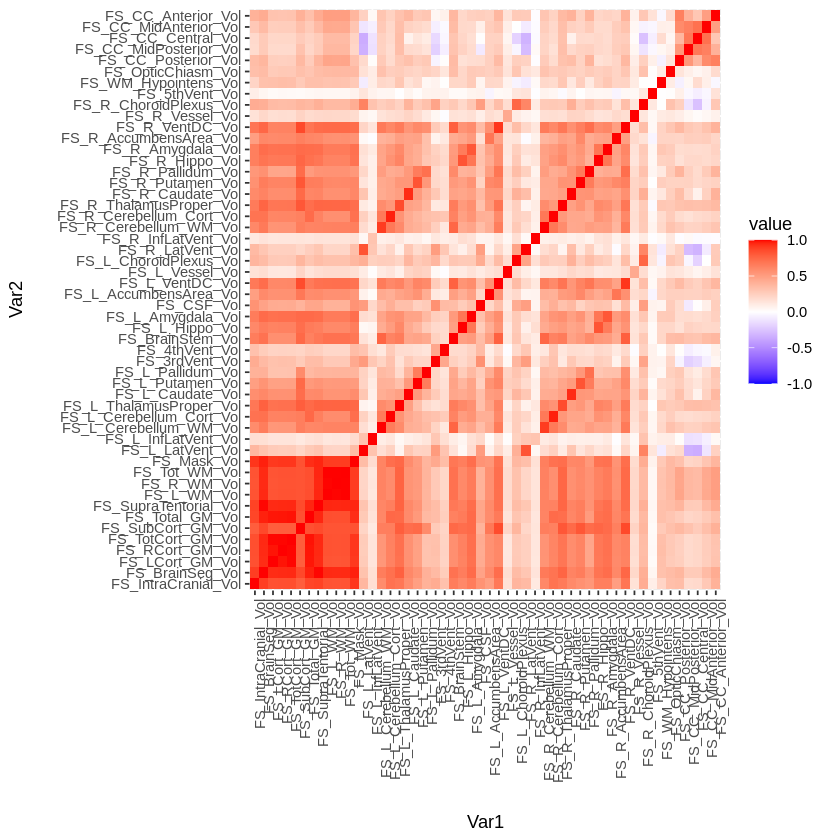

In [13]:
# WRITE YOUR CODE HERE
ggplot(fs_cor_melt, aes(x=Var1, y=Var2, fill=value)) +
  geom_tile() +
  scale_fill_gradient2(low="blue", mid="white", high="red", limits=c(-1,1)) +
  theme(axis.text.x = element_text(angle=90, hjust=1))

What patterns do you see in the correlations?

> The freesurfer volume measures are highly positively correlated with each other, indicating strong shared structure across brain regions. This suggests redundancy and that many variables capture similar underlying anatomical variation.


---
## 3. Principal component analysis (3 points)

Let's see how many principal components explain at *at least* 95% of the data.

(a) Create a new object called `fs_d.pca` using the `princomp` function (do not forget to scale the data).


In [14]:
# WRITE YOUR CODE HERE
fs_d.pca <- princomp(fs_only, scale=TRUE)
summary(fs_d.pca)

Warning message:
“In princomp.default(fs_only, scale = TRUE) :
 extra argument ‘scale’ will be disregarded”


Importance of components:
                             Comp.1       Comp.2       Comp.3       Comp.4
Standard deviation     3.172141e+05 6.576735e+04 3.269422e+04 3.154782e+04
Proportion of Variance 9.384239e-01 4.033804e-02 9.968642e-03 9.281817e-03
Cumulative Proportion  9.384239e-01 9.787619e-01 9.887306e-01 9.980124e-01
                             Comp.5       Comp.6       Comp.7       Comp.8
Standard deviation     1.150332e+04 6.670165e+03 3.362328e+03 3.240693e+03
Proportion of Variance 1.234073e-03 4.149228e-04 1.054325e-04 9.794225e-05
Cumulative Proportion  9.992464e-01 9.996614e-01 9.997668e-01 9.998647e-01
                             Comp.9      Comp.10      Comp.11      Comp.12
Standard deviation     2.284236e+03 1.501755e+03 1.302839e+03 1.225383e+03
Proportion of Variance 4.866045e-05 2.103256e-05 1.582980e-05 1.400355e-05
Cumulative Proportion  9.999134e-01 9.999344e-01 9.999503e-01 9.999643e-01
                            Comp.13      Comp.14      Comp.15      Comp.16

(b) Calculate the cumulative variance explained (not unique variance explained as in the tutorial) across the principal components and plot the results using `ggplot`.

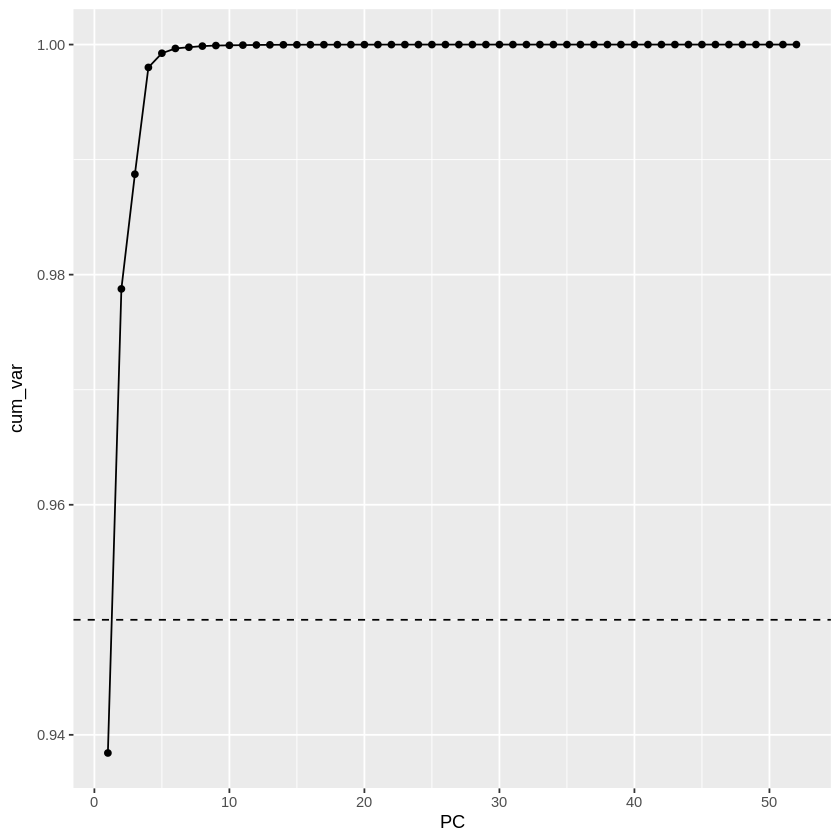

In [15]:
# WRITE YOUR CODE HERE
var_explained <- fs_d.pca$sdev^2 / sum(fs_d.pca$sdev^2)
cum_var <- cumsum(var_explained)

df_pca <- data.frame(
  PC = 1:length(cum_var),
  cum_var = cum_var
)

ggplot(df_pca, aes(x=PC, y=cum_var)) +
  geom_line() +
  geom_point() +
  geom_hline(yintercept=0.95, linetype="dashed")

(c) Determine exactly how many principal components explain at least 95% of the variance.

Hint: Look up the `which` function.

In [16]:
# WRITE YOUR CODE HERE
which(cum_var >= 0.95)[1]

Comp.2 
     2

What does this tell you about the underlying dimensionality of the brain volume measures?

> A relatively small number of principal components explain most of the variance, indicating that brain volume measures have low intrinsic dimensionality and share common underlying structure.


---
## 4. Associating with Flanker task peformance (4 points)

Now apply PCR to the `d1` object you created at the beginning (which includes the Flanker task scores) to find how freesurfer volumes predict Flanker task performance. Set the random seed to "2". Use cross-validation as the validation type and don't forget to scale your data. Show the `summary` of the model fit.

Hint: If you receive an error applying the "scale=TRUE" flag, then you likely still have columns of all zeros somewhere in your data table.

In [17]:
# WRITE YOUR CODE HERE
set.seed(13)

pcr_model <- pcr(
  Flanker_Unadj ~ .,
  data = d1,
  scale = TRUE,
  validation = "CV"
)

summary(pcr_model)

Data: 	X dimension: 1113 52 
	Y dimension: 1113 1
Fit method: svdpc
Number of components considered: 52

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           10.08    9.928    9.928    9.934    9.918    9.922    9.919
adjCV        10.08    9.927    9.927    9.932    9.916    9.919    9.916
       7 comps  8 comps  9 comps  10 comps  11 comps  12 comps  13 comps
CV       9.907    9.921    9.928     9.944     9.953     9.965     9.962
adjCV    9.903    9.916    9.923     9.938     9.947     9.958     9.954
       14 comps  15 comps  16 comps  17 comps  18 comps  19 comps  20 comps
CV        9.974     9.980     9.977     9.948      9.93     9.941     9.934
adjCV     9.965     9.972     9.969     9.933      9.92     9.929     9.923
       21 comps  22 comps  23 comps  24 comps  25 comps  26 comps  27 comps
CV        9.937     9.945     9.971     9.985     9.998     10.01     9.999
adjCV     9.926  

(b) Use the `validationplot` function to evaluate the bias-variance tradeoff using the cross-validated mean squared-error for each component.

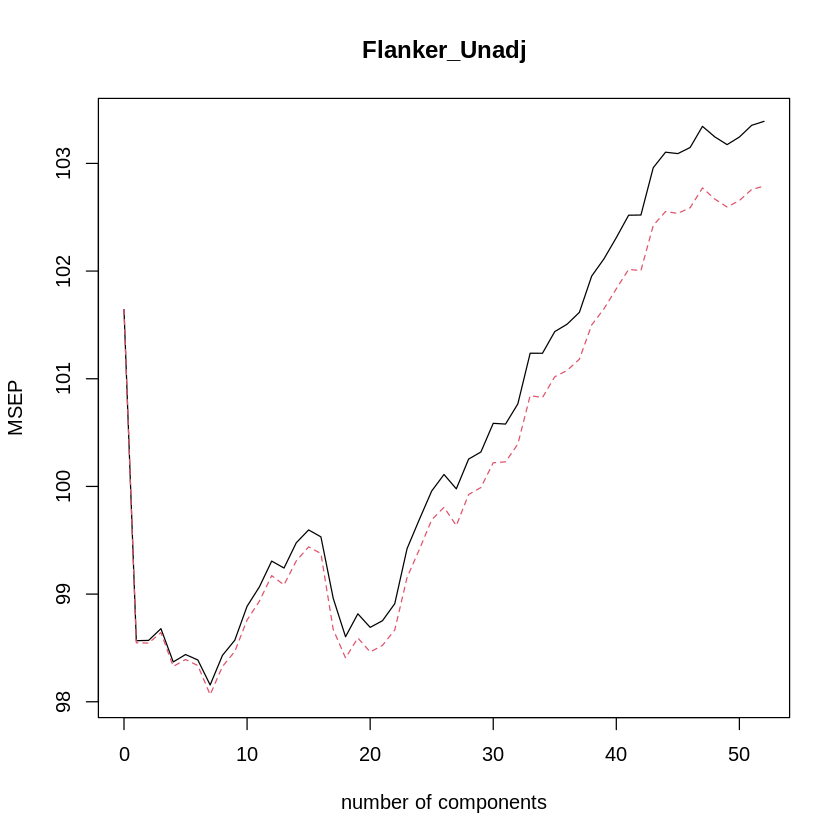

In [18]:
# WRITE YOUR CODE HERE
validationplot(pcr_model, val.type = "MSEP")

(c) Extract the MSEP values of the cross validated fit ("CV" not "adj_CV") from the model object using the `MSEP` funtion. Create a new array of these values. Use the `drop` function to remove the singleton dimension (the original array is 2x1x53 and we want a 2x53 object). Find the minimum value of the first row (the "CV").

In [20]:
# WRITE YOUR CODE HERE
msep_vals <- MSEP(pcr_model, estimate = "CV")$val
msep_vals <- drop(msep_vals)

min(msep_vals)

[1] 98.15607

What what does this plot tell you about how many components best explain variance in Flanker task performance?

> The validation plot shows that only a small number of components minimize prediction error, suggesting that only a subset of the variance in brain volumes is relevant for predicting Flanker task performance.

---
## 5. Reflection (2 points)

Compare the number of components that explain variance in X alone (the brain volumes) to the number of components that explain performance in the Flanker task. What does the difference in these two numbers tell you about how variation in brain volumes relates to task performance?

> While many principal components are needed to explain variance in brain volumes alone, far fewer components are needed to predict Flanker task performance. This indicates that only specific patterns of brain volume variation are relevant for cognitive performance, and much of the variance in brain structure does not contribute to behavior.
>

**DUE:** 5pm EST, April 9, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*